# Cube-Single Subgoal Visualisation

Visualises predicted subgoals for **OTA** and **HIQL-Dual-DAF** on `cube-single`.
The high-level actor's latent prediction is decoded to world (X, Y) via a Ridge regression
linear probe, then projected to pixel coords and overlaid on rendered frames.


In [24]:
# ── Headless rendering fix  (must precede mujoco imports) ─────────────────────
import os, sys, base64
os.environ['MUJOCO_GL'] = 'egl'           # swap to 'osmesa' if no GPU
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from IPython.display import HTML, display
from PIL import Image, ImageDraw
import imageio.v2 as imageio
from sklearn.linear_model import Ridge
import jax, jax.numpy as jnp, mujoco
import gymnasium as gym, ogbench, ogbench.manipspace
from utils.flax_utils import restore_agent
from agents.ota.original import OTAAgent, get_config as get_config_ota
from agents.pi_hiql.hiql_dual_daf import HIQLDualDAFAgent, get_config as get_config_hiql

DATA_DIR  = 'toy_data/cube_single'
CKPT_OTA  = '/home/m_bobrin/dual-goal-representations/results/ota/cube-single-play-v0_ota_sd000/checkpoints'
CKPT_HIQL = '/home/m_bobrin/dual-goal-representations/results/hiql_dual_daf/cube-single-play/checkpoints'

XYZ_C = np.array([0.425, 0.0, 0.0]); XYZ_S = 10.0; GS = 3.0; CUB = 0.04
X_RNG = (0.30, 0.55); Y_RNG = (-0.30, 0.30)
TASKS = {
    1: dict(name='horizontal', init_xyz=np.array([0.425, 0.1,0.02]), goal_xyz=np.array([0.425,-0.1,0.02])),
    2: dict(name='vertical1',  init_xyz=np.array([0.350, 0.0,0.02]), goal_xyz=np.array([0.500, 0.0,0.02])),
    3: dict(name='vertical2',  init_xyz=np.array([0.500, 0.0,0.02]), goal_xyz=np.array([0.350, 0.0,0.02])),
    4: dict(name='diagonal1',  init_xyz=np.array([0.350,-0.2,0.02]), goal_xyz=np.array([0.500, 0.2,0.02])),
    5: dict(name='diagonal2',  init_xyz=np.array([0.350, 0.2,0.02]), goal_xyz=np.array([0.500,-0.2,0.02])),
}

def eff(obs):  return obs[...,12:15]/XYZ_S + XYZ_C
def blk(obs, k=0): s=19+k*9; return obs[...,s:s+3]/XYZ_S + XYZ_C

def load_traj(data_dir, task_id):
    d = dict(np.load(f'{data_dir}/task{task_id}.npz', allow_pickle=True))
    obs = d.get('observations', next(iter(d.values())))
    print(f'  task{task_id}.npz: {len(obs)} steps'); return d

def first_episode(d):
    obs = d.get('observations', next(iter(d.values()))).astype(np.float32)
    if 'terminals' in d: obs = obs[:int(np.argmax(d['terminals'].astype(bool)))+1]
    return obs

def make_env(task_id, sz=200):
    env = gym.make('cube-single-v0', render_mode='rgb_array', width=sz, height=sz)
    env.reset(options={'task_id': task_id}); return env

def set_state(env, obs):
    r = env.unwrapped
    r._data.qpos[r._arm_joint_ids] = obs[0:6]
    r._data.qvel[r._arm_joint_ids] = obs[6:12]
    r._data.qpos[r._gripper_opening_joint_id] = float(np.clip(obs[17]/GS,0,1))*0.8
    r._data.joint('object_joint_0').qpos[:3] = obs[19:22]/XYZ_S + XYZ_C
    r._data.joint('object_joint_0').qpos[3:]  = obs[22:26]
    mujoco.mj_forward(r._model, r._data)

def resize(env, sz):
    r = env.unwrapped
    if r._render_width != sz:
        r._render_width = r._render_height = sz
        if r._renderer: r._renderer.close()
        r._renderer = None

def get_cam(env, name='front_pixels'):
    m = env.unwrapped._model
    cid = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_CAMERA, name)
    if cid < 0: cid, name = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_CAMERA, 'front'), 'front'
    return cid, name

def w2px(model, data, cid, pt, W, H):
    cp = data.cam_xpos[cid].copy(); cm = data.cam_xmat[cid].copy().reshape(3,3)
    c = cm.T @ (np.asarray(pt,float)-cp); d = -c[2]
    if d < 1e-4: return None
    f = (H/2)/np.tan(np.radians(model.cam_fovy[cid])/2)
    return np.array([W/2+f*c[0]/d, H/2-f*c[1]/d])

def precalc_px(env, obs_seq, cam='front_pixels'):
    r = env.unwrapped; m=r._model; da=r._data; W=r._render_width; H=r._render_height
    cid,cam = get_cam(env,cam); set_state(env,obs_seq[0])
    return cid,cam,[w2px(m,da,cid,p,W,H) for p in eff(obs_seq)],[w2px(m,da,cid,p,W,H) for p in blk(obs_seq)]

def pickup_idx(obs_seq, thr=0.032, mi=5):
    z = blk(obs_seq)[:,2]; c = np.where(z>thr)[0]; c=c[c>mi]
    return int(c[0]) if len(c) else len(obs_seq)-1

def pregrasp(obs_seq, pi, n=8):
    return list(range(max(0, pi-n), pi))

def reticle(draw, cx, cy, r=5, col=(255,215,0)):
    ring = r+5
    draw.ellipse([cx-ring,cy-ring,cx+ring,cy+ring], outline=(*col,180), width=1)
    draw.ellipse([cx-r,cy-r,cx+r,cy+r], fill=(*col,220))
    for dx,dy in [(-1,0),(1,0),(0,-1),(0,1)]:
        draw.line([(cx+dx*(ring+2),cy+dy*(ring+2)),(cx+dx*(ring+7),cy+dy*(ring+7))], fill=(*col,200), width=2)

print('Setup complete.')

Setup complete.


## Subgoal Prediction Core

| Agent | Representation space | Probe fitted |
|-------|----------------------|--------------|
| OTA | `goal_rep([obs; g])` — obs-dependent | per query frame |
| HIQL | `psi(g) = rep_value(g)` — goal-only | **once** per trajectory |


In [25]:
@jax.jit
def _ota_rep(network, obs, goal):
    r = network.select('high_actor')(obs, goal).mode()
    return r / jnp.linalg.norm(r, axis=-1, keepdims=True) * jnp.sqrt(r.shape[-1])

@jax.jit
def _ota_greps(network, cat): return network.select('goal_rep')(cat)

@jax.jit
def _hiql_rep(network, obs, goal):
    r = network.select('high_actor')(obs, goal).mode()
    n = jnp.linalg.norm(r, axis=-1, keepdims=True) + 1e-8
    return r / n * jnp.sqrt(r.shape[-1])

@jax.jit
def _hiql_psi(network, goals):
    p = network.select('rep_value')(goals)
    n = jnp.linalg.norm(p, axis=-1, keepdims=True) + 1e-8
    return p / n * jnp.sqrt(p.shape[-1])

def fit_ota_probe(agent, ref_obs, traj_obs):
    M = len(traj_obs)
    cat = jnp.concatenate([jnp.tile(jnp.array(ref_obs)[None],(M,1)), jnp.array(traj_obs)],axis=-1)
    reps = np.array(_ota_greps(agent.network, cat))
    return Ridge(alpha=0.1).fit(reps, blk(traj_obs)[:,:2])

def fit_hiql_probe(agent, traj_obs):
    psi = np.array(_hiql_psi(agent.network, jnp.array(traj_obs)))
    return Ridge(alpha=0.1).fit(psi, blk(traj_obs)[:,:2])

def predict_sg_xyz(agent, atype, obs, goal_obs, traj_obs, hiql_probe=None):
    """
    Decode high-level actor subgoal -> block world (X, Y, Z=0.02).
    OTA:  probe refitted per call (goal_rep is obs-dependent).
    HIQL: pass pre-fitted hiql_probe; auto-fitted if None.
    """
    oj, gj = jnp.array(obs[None]), jnp.array(goal_obs[None])
    if atype == 'ota':
        probe  = fit_ota_probe(agent, obs, traj_obs)
        sg_rep = np.array(_ota_rep(agent.network, oj, gj))[0]
    elif atype == 'hiql':
        probe  = hiql_probe if hiql_probe is not None else fit_hiql_probe(agent, traj_obs)
        sg_rep = np.array(_hiql_rep(agent.network, oj, gj))[0]
    else:
        raise ValueError(f'Unknown agent_type {atype!r}')
    xy = probe.predict(sg_rep[None])[0]
    return np.array([xy[0], xy[1], 0.02])

print('Subgoal prediction ready.')

Subgoal prediction ready.


In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Load agents from checkpoints
# ═══════════════════════════════════════════════════════════════════════════════
TASK_ID  = 1
d        = load_traj(DATA_DIR, TASK_ID)
obs_seq  = first_episode(d)
goal_obs = obs_seq[-1]           # task-completion state as goal
ex_obs   = obs_seq[:1]
ex_act   = d.get('actions', np.zeros((1,5), np.float32))[:1]

# ── OTA ───────────────────────────────────────────────────────────────────────
cfg_ota = get_config_ota()
cfg_ota.rep_dim = 256           # adjust to match your checkpoint
ota = OTAAgent.create(0, ex_obs, ex_act, cfg_ota)
ota = restore_agent(ota, CKPT_OTA, step=500_000)
print('OTA loaded.')

# ── HIQL-Dual-DAF ─────────────────────────────────────────────────────────────
cfg_hiql = get_config_hiql()    # goalrep_dim=256 by default
hiql = HIQLDualDAFAgent.create(0, ex_obs, ex_act, cfg_hiql)
hiql = restore_agent(hiql, CKPT_HIQL, step=1_000_000)
print('HIQL loaded.')

  task1.npz: 64 steps
Restored agent from step 500000 in /home/m_bobrin/dual-goal-representations/results/ota/cube-single-play-v0_ota_sd000/checkpoints
OTA loaded.


Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/hiql_dual_daf/cube-single-play/checkpoints
HIQL loaded.


## Expert Trajectory — Subgoal Visualisation

Paper-quality figure: rendered pre-pickup frames with gold reticle = predicted subgoal,
and a 2-D bird's-eye view with arrows showing the agent's misaligned block target.


  task1.npz: 64 steps


/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


[ota video] Computing 60 subgoals ...
  10/60
  20/60
  30/60
  40/60
  50/60
  60/60
  Rendering ...
  Saved -> ota_expert_subgoals.gif
  Done.



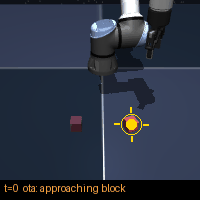

[hiql video] Computing 60 subgoals ...
  10/60
  20/60
  30/60
  40/60
  50/60
  60/60
  Rendering ...


/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


  Saved -> hiql_expert_subgoals.gif
  Done.



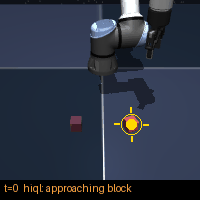

In [29]:
def _draw_2d_bg(obs_seq, task_id, ax):
    ep, bp = eff(obs_seq), blk(obs_seq); N = len(obs_seq)
    for i in range(N-1):
        t=i/max(N-2,1)
        ax.plot(ep[i:i+2,0],ep[i:i+2,1],color=(t,0,1-t,0.22),lw=1.2)
        ax.plot(bp[i:i+2,0],bp[i:i+2,1],color=(0.9-0.85*t,0.1+0.85*t,0,0.18),lw=1.8,ls='--')
    task=TASKS[task_id]; h=CUB/2
    ix,iy=task['init_xyz'][:2]; gx,gy=task['goal_xyz'][:2]
    ax.add_patch(mpatches.Rectangle((ix-h,iy-h),CUB,CUB,lw=2,edgecolor='crimson',facecolor=(1,.3,.3,.18),label='Block init'))
    ax.add_patch(mpatches.Rectangle((gx-h,gy-h),CUB,CUB,lw=2,edgecolor='limegreen',ls='--',facecolor=(.3,1,.3,.18),label='Goal'))
    ax.set_xlim(X_RNG[0]-.05,X_RNG[1]+.05); ax.set_ylim(Y_RNG[0]-.05,Y_RNG[1]+.05)
    ax.set_aspect('equal'); ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]'); ax.grid(True,alpha=0.18)


def visualize_expert_subgoals(agent, atype, obs_seq, goal_obs, task_id, env,
                               n=6, sz=360, cam='front_pixels', save=None, dpi=200):
    pi      = pickup_idx(obs_seq)
    pre     = pregrasp(obs_seq, pi, n=n)
    K       = len(pre)
    if K == 0: raise ValueError('No pre-grasp window. Lower lift_thresh or increase n.')
    print(f'[{atype}] pickup t={pi}  pregrasp t={pre[0]}-{pre[-1]}')
    resize(env, sz)

    # Fit HIQL probe once; OTA probe is per-frame
    hp = fit_hiql_probe(agent, obs_seq) if atype == 'hiql' else None
    sg_all = np.array([predict_sg_xyz(agent, atype, obs_seq[i], goal_obs, obs_seq, hp) for i in pre])

    print(f'  Rendering {K} frames ...')
    raw  = env.unwrapped; model=raw._model; data=raw._data; W,H=sz,sz
    cid, cam = get_cam(env, cam)
    frames = []
    for k, ti in enumerate(pre):
        set_state(env, obs_seq[ti])
        img  = Image.fromarray(raw.render(camera=cam)).convert('RGBA')
        draw = ImageDraw.Draw(img, 'RGBA')
        px   = w2px(model, data, cid, sg_all[k], W, H)
        if px is not None:
            cx,cy = int(px[0]),int(px[1])
            reticle(draw, cx, cy, r=6, col=(255,215,0))
            lw = len(atype)*7+70
            draw.rectangle([cx+14,cy-11,cx+14+lw,cy+9], fill=(0,0,0,150))
            draw.text((cx+17,cy-9), f'{atype} subgoal', fill=(255,215,0,230))
        frames.append(np.array(img.convert('RGB')))

    fig = plt.figure(figsize=(3*K,9.5), facecolor='white')
    gs  = gridspec.GridSpec(2,K,figure=fig,left=.03,right=.97,top=.91,bottom=.04,
                             hspace=0.28,wspace=0.04,height_ratios=[1.3,1.0])
    for col,(frame,ti) in enumerate(zip(frames,pre)):
        ax=fig.add_subplot(gs[0,col]); ax.imshow(frame,interpolation='lanczos'); ax.axis('off')
        ax.set_title(f't={ti}  ({int(ti/max(len(obs_seq)-1,1)*100)}%)', fontsize=9, pad=3)

    ax2 = fig.add_subplot(gs[1,:])
    _draw_2d_bg(obs_seq, task_id, ax2)
    ep = eff(obs_seq)
    ax2.scatter(ep[pre,0],ep[pre,1],c='dodgerblue',s=80,zorder=9,edgecolors='navy',lw=1.2,label='Arm (pre-pickup)')
    ax2.scatter(sg_all[:,0],sg_all[:,1],c='gold',s=200,zorder=10,marker='*',edgecolors='darkorange',lw=1.0,label=f'{atype} subgoal (block XY)')
    for k in range(K):
        ax2.annotate('',xy=(sg_all[k,0],sg_all[k,1]),xytext=(ep[pre[k],0],ep[pre[k],1]),
                     arrowprops=dict(arrowstyle='-|>',color='gray',alpha=0.5,lw=1.2,mutation_scale=10))
    pi2=min(pi,len(obs_seq)-1)
    ax2.scatter(ep[pi2,0],ep[pi2,1],c='red',s=150,zorder=11,marker='^',edgecolors='darkred',lw=1.5,label='Pickup')
    ax2.legend(fontsize=8,ncol=2)
    ax2.set_title('2-D XY  —  gold stars = predicted subgoal block position',fontsize=9)
    task=TASKS[task_id]
    fig.suptitle(f'{atype.upper()} Predicted Subgoals  —  Task {task_id} ({task["name"]})\n'
                 f'Gold = where the agent thinks the block SHOULD be (linear probe)',
                 fontsize=12,fontweight='bold',y=0.97)
    if save:
        fig.savefig(save,dpi=dpi,bbox_inches='tight',facecolor='white')
        print(f'  Saved -> {save}')
    return fig


def subgoal_video(agent, atype, obs_seq, goal_obs, task_id, env,
    sz=200, fps=8, max_frames=60, tstep=2, save_path=None):
    """
    Full-trajectory GIF: trajectory traces + gold reticle at predicted subgoal.
    save_path: if given (e.g. "ota_rollout.gif"), also writes the GIF to disk.
    """
    N_full   = len(obs_seq)
    imap     = np.linspace(0, N_full-1, min(max_frames, N_full), dtype=int)
    obs_vis  = obs_seq[imap]; N = len(obs_vis)
    pi       = pickup_idx(obs_seq)
    resize(env, sz)

    raw = env.unwrapped; model=raw._model; data=raw._data; W,H=sz,sz
    cid, cam, epx, bpx = precalc_px(env, obs_vis)

    # HIQL probe: fit once (psi is obs-independent); OTA: per frame
    hp = fit_hiql_probe(agent, obs_seq) if atype == 'hiql' else None
    print(f'[{atype} video] Computing {N} subgoals ...')
    sgpx = []
    for i, obs in enumerate(obs_vis):
        sg = predict_sg_xyz(agent, atype, obs, goal_obs, obs_seq, hp)
        sgpx.append(w2px(model, data, cid, sg, W, H))
        if (i+1) % 10 == 0: print(f'  {i+1}/{N}')

    print('  Rendering ...')
    frames, st = [], max(1, tstep)
    for i, obs in enumerate(obs_vis):
        set_state(env, obs)
        img  = Image.fromarray(raw.render(camera=cam)).convert('RGBA')
        draw = ImageDraw.Draw(img, 'RGBA')

        # Trajectory traces
        past = list(range(0, i+1, st))
        for k in range(len(past)-1):
            j0,j1 = past[k],past[k+1]; t=(j0+j1)/2/max(N-1,1)
            if epx[j0] is not None and epx[j1] is not None:
                draw.line([(int(epx[j0][0]),int(epx[j0][1])),(int(epx[j1][0]),int(epx[j1][1]))],
                          fill=(int(255*t),0,int(255*(1-t)),200),width=2)
            if bpx[j0] is not None and bpx[j1] is not None:
                draw.line([(int(bpx[j0][0]),int(bpx[j0][1])),(int(bpx[j1][0]),int(bpx[j1][1]))],
                          fill=(int(220*(1-t)),int(200*t),30,200),width=3)

        # Gold subgoal reticle
        if sgpx[i] is not None:
            reticle(draw, int(sgpx[i][0]), int(sgpx[i][1]), r=5, col=(255,215,0))

        # Phase banner
        ti    = int(imap[i])
        phase = 'approaching block' if ti < pi else 'grasping / placing'
        col   = (255,165,60,220) if ti < pi else (100,230,100,220)
        draw.rectangle([0,H-20,W,H],fill=(0,0,0,130))
        draw.text((4,H-18),f't={ti}  {atype}: {phase}',fill=col)
        frames.append(np.array(img.convert('RGB')))

    tmp = f'/tmp/{atype}_rollout_task{task_id}.gif'
    imageio.mimwrite(tmp, frames, format='GIF', fps=fps, loop=0)
    if save_path is not None:
        import shutil as _sh; _sh.copy(tmp, save_path)
        print(f'  Saved -> {save_path}')
    with open(tmp,'rb') as f: b64=base64.b64encode(f.read()).decode()
    print('  Done.')
    return HTML(f'<h3>{atype.upper()} rollout — Task {task_id}</h3>'
                f'<p style="font-size:12px"><b>Gold reticle</b> = predicted subgoal block XY | '
                f'blue-red = arm | orange-green = block</p>'
                f'<img src="data:image/gif;base64,{b64}" style="width:{sz*2}px; image-rendering:pixelated"/>')

# ── Run for both agents ───────────────────────────────────────────────────────
TASK_ID  = 1
d        = load_traj(DATA_DIR, TASK_ID)
obs_seq  = first_episode(d)
goal_obs = obs_seq[-1]
env      = make_env(TASK_ID, sz=360)

# fig_ota  = visualize_expert_subgoals(ota,  'ota',  obs_seq, goal_obs, TASK_ID, env, save='ota_expert_subgoals.pdf')
# plt.show()

# fig_hiql = visualize_expert_subgoals(hiql, 'hiql', obs_seq, goal_obs, TASK_ID, env, save='hiql_expert_subgoals.pdf')
# plt.show()

# ── Video: full expert trajectory with subgoal reticle updated every frame ────
# Uses the same subgoal_video() function as the rollout cell — just pass obs_seq.
# env.reset restores the goal mocap marker so it appears in the rendered frames.

env.reset(options={'task_id': TASK_ID})
display(subgoal_video(ota, 'ota', obs_seq, goal_obs, TASK_ID, env, sz=200, save_path='ota_expert_subgoals.gif'))

# Un-comment for HIQL:
env.reset(options={'task_id': TASK_ID})
display(subgoal_video(hiql, 'hiql', obs_seq, goal_obs, TASK_ID, env, sz=200, save_path='hiql_expert_subgoals.gif'))

## Own Rollout — Model-Driven Trajectory with Subgoal Video

Roll out each agent's own policy (no expert demos) and visualise the predicted subgoal
block position at every frame as an animated GIF.


/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(
/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Rolling out OTA on Task 4


  Steps: 201  |  Success: False
[ota video] Computing 60 subgoals ...
  10/60
  20/60
  30/60
  40/60
  50/60
  60/60
  Rendering ...
  Saved -> ota_rollout_task4.gif
  Done.



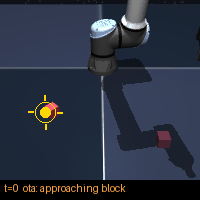

Rolling out HIQL on Task 4


/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


  Steps: 201  |  Success: False
[hiql video] Computing 60 subgoals ...
  10/60
  20/60
  30/60
  40/60
  50/60
  60/60
  Rendering ...
  Saved -> hiql_rollout_task4.gif
  Done.



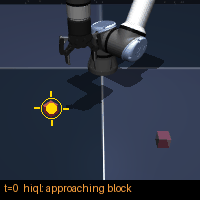

In [28]:
def rollout(agent, env, task_id, max_steps=200, seed=0, temp=0.0):
    """Roll out agent with sample_actions(obs, goal, seed, temperature) API."""
    obs, info = env.reset(options={'task_id': task_id})
    raw    = env.unwrapped
    goal = info.get("goal") 
    if goal is None: raise RuntimeError('_cur_goal_ob is None — env must be in task mode.')
    seq, success, rng = [obs.copy()], False, jax.random.key(seed)
    for _ in range(max_steps):
        rng, srng = jax.random.split(rng)
        action = np.array(agent.sample_actions(jnp.array(obs[None]),jnp.array(goal[None]),seed=srng,temperature=temp)[0])
        obs, _, term, trunc, info = env.step(action)
        seq.append(obs.copy())
        success = bool(info.get('success', False))
        if term or trunc: break
    return np.array(seq, np.float32), np.array(goal, np.float32), success

# ── Roll out both agents ──────────────────────────────────────────────────────
TASK_ID = 4
env_r   = make_env(TASK_ID, sz=200)

for agent, atype in [(ota, 'ota'), (hiql, 'hiql')]:
    print('='*60)
    print(f'Rolling out {atype.upper()} on Task {TASK_ID}')
    obs_r, goal_r, ok = rollout(agent, env_r, TASK_ID, seed=0)
    print(f'  Steps: {len(obs_r)}  |  Success: {ok}')
    env_r.reset(options={'task_id': TASK_ID})
    display(subgoal_video(agent, atype, obs_r, goal_r, TASK_ID, env_r,
                          save_path=f'{atype}_rollout_task{TASK_ID}.gif'))